# 04b. Feature Selection — Reducir features que no aportan

**Objetivo**: De las 94 features actuales, identificar y eliminar las que no aportan poder predictivo.

**Pipeline**:
1. **Varianza casi-cero**: drop cols con varianza < 0.001 (sanity)
2. **Correlación entre features**: drop pares con |corr| > 0.95 (redundancia)
3. **Permutation importance** sobre XGBoost: cuánto baja AUC al permutar cada col
4. **RFECV** con XGBoost + CV 5-fold: selección recursiva con CV
5. Comparar XGBoost completo vs reducido

**Outputs**:
- `data/X_train_reducido.parquet`, `data/X_test_reducido.parquet`
- `data/features_seleccionadas.csv`
- `figuras/dia_04b_*.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

sns.set_style('whitegrid')
RAIZ_MODELO = Path('..').resolve()
DATA = RAIZ_MODELO / 'data'
FIGS = RAIZ_MODELO / 'figuras'
MODELOS = DATA / 'modelos'
RANDOM_STATE = 42
print('Imports OK')

Imports OK


In [2]:
X_train = pd.read_parquet(DATA / 'X_train.parquet')
X_test = pd.read_parquet(DATA / 'X_test.parquet')
y_train = pd.read_parquet(DATA / 'y_train.parquet').iloc[:, 0]
y_test = pd.read_parquet(DATA / 'y_test.parquet').iloc[:, 0]
xgbm = joblib.load(MODELOS / 'xgb.pkl')

print(f'X_train: {X_train.shape}')
print(f'XGB cargado: {xgbm.n_estimators} arboles, depth={xgbm.max_depth}')

X_train: (38664, 94)
XGB cargado: 300 arboles, depth=6


## Paso 1: Variance Threshold

Cualquier col con varianza < 0.001 es constante o casi → no aporta.

Fast win: muchas columnas OHE con clase rara (ej: `documentos_tipo_categoria_X`)
pueden estar en ~0% del dataset.

In [3]:
vt = VarianceThreshold(threshold=0.001)
vt.fit(X_train)

cols_baja_varianza = X_train.columns[~vt.get_support()].tolist()
cols_buenas_var = X_train.columns[vt.get_support()].tolist()

print(f'Cols con varianza > 0.001: {len(cols_buenas_var)}')
print(f'Cols dropped (varianza casi cero): {len(cols_baja_varianza)}')
if cols_baja_varianza:
    print(f'  Ejemplos: {cols_baja_varianza[:10]}')

X_train_v1 = X_train[cols_buenas_var]
X_test_v1 = X_test[cols_buenas_var]
print(f'\nShape post varianza: {X_train_v1.shape}')

Cols con varianza > 0.001: 84
Cols dropped (varianza casi cero): 10
  Ejemplos: ['rama_Legislativo', 'condiciones_de_entrega_CFR - Cost and freight', 'condiciones_de_entrega_CIF - Coste, seguro y flete (puerto de destino convenido)', 'condiciones_de_entrega_CIP - Carriage and insurance paid to', 'condiciones_de_entrega_CPT - Transporte pagado hasta (lugar de destino convenido)', 'condiciones_de_entrega_DDP - Delivery duty place', 'condiciones_de_entrega_EXW - Ex-Works', 'condiciones_de_entrega_FCA - Free Carrier', 'condiciones_de_entrega_Transporte a cargo del comprador', 'condiciones_de_entrega_Transporte no incluído']

Shape post varianza: (38664, 84)


## Paso 2: Correlación entre features

Si dos cols tienen |corr| > 0.95, son redundantes. Drop una.

Heurística: cuando hay pares correlacionados, dropear la que tenga **menor**
correlación con el target (la que aporta menos señal predictiva).

In [4]:
UMBRAL_CORR = 0.95

corr_matrix = X_train_v1.corr().abs()
# Solo triangulo superior
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Pares correlacionados
pares = []
for col in upper.columns:
    for idx in upper.index:
        v = upper.loc[idx, col]
        if pd.notna(v) and v > UMBRAL_CORR:
            pares.append((idx, col, v))

print(f'Pares con |corr| > {UMBRAL_CORR}: {len(pares)}')
for a, b, v in pares[:15]:
    print(f'  {a:<35} <->  {b:<35}  corr={v:.3f}')

# Para cada par, drop la col con menor corr al target
corr_target = X_train_v1.corrwith(y_train).abs()
cols_drop_corr = set()
for a, b, _ in pares:
    if a in cols_drop_corr or b in cols_drop_corr:
        continue
    if corr_target[a] < corr_target[b]:
        cols_drop_corr.add(a)
    else:
        cols_drop_corr.add(b)

print(f'\nCols a dropear por correlacion redundante: {len(cols_drop_corr)}')
print(f'  {sorted(cols_drop_corr)}')

cols_post_corr = [c for c in X_train_v1.columns if c not in cols_drop_corr]
X_train_v2 = X_train_v1[cols_post_corr]
X_test_v2 = X_test_v1[cols_post_corr]
print(f'\nShape post correlacion: {X_train_v2.shape}')

Pares con |corr| > 0.95: 24
  orden_Nacional                      <->  orden_Territorial                    corr=0.970
  entidad_centralizada_Centralizada   <->  entidad_centralizada_Descentralizada  corr=1.000
  es_grupo_No                         <->  es_grupo_Si                          corr=1.000
  es_pyme_No                          <->  es_pyme_Si                           corr=1.000
  obligaci_n_ambiental_No             <->  obligaci_n_ambiental_Si              corr=1.000
  origen_de_los_recursos_Distribuido  <->  origen_de_los_recursos_Recursos Propios  corr=1.000
  destino_gasto_Funcionamiento        <->  destino_gasto_Inversión              corr=0.962
  estado_bpin_No Válido               <->  estado_bpin_Válido                   corr=1.000
  el_contrato_puede_ser_prorrogado_No <->  el_contrato_puede_ser_prorrogado_Si  corr=1.000
  documentos_tipo_No                  <->  documentos_tipo_Si                   corr=1.000
  pliego_rentabilidad_activo_min_pct_was_nan <->  pliego_

## Paso 3: Permutation Importance

**Cómo funciona**:
1. Tomar modelo entrenado (XGB)
2. Para cada feature, permutarla aleatoriamente (rompe la relación con y)
3. Medir caída en AUC vs original
4. Si la caída es ~0 → la feature no aporta

**Más robusto que `feature_importances_`** porque mide impacto REAL en predicción,
no solo cuántas veces se usa la col en splits del árbol.

Reentrenamos XGB sobre el dataset post-correlación.

In [5]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgbm_v2 = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=spw, n_jobs=-1, random_state=RANDOM_STATE,
    tree_method='hist',
)
xgbm_v2.fit(X_train_v2, y_train)

auc_v2 = roc_auc_score(y_test, xgbm_v2.predict_proba(X_test_v2)[:, 1])
print(f'XGB sobre {X_train_v2.shape[1]} cols — AUC test: {auc_v2:.4f}')

XGB sobre 67 cols — AUC test: 0.9017


In [6]:
# Permutation importance (puede tardar 1-3 min sobre 9667 rows × N cols)
t0 = time.time()
perm = permutation_importance(
    xgbm_v2, X_test_v2, y_test,
    n_repeats=5,           # 5 permutaciones por feature
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='roc_auc',
)
print(f'Permutation importance calculado en {time.time()-t0:.1f}s')

perm_df = pd.DataFrame({
    'feature': X_train_v2.columns,
    'mean_drop_auc': perm.importances_mean,
    'std_drop_auc': perm.importances_std,
}).sort_values('mean_drop_auc', ascending=False)

print('\nTop 20 (mayor caida AUC al permutar):')
print(perm_df.head(20).to_string(index=False))

print('\nBottom 20 (caida AUC ≈ 0 — candidatos a drop):')
print(perm_df.tail(20).to_string(index=False))

Permutation importance calculado en 8.1s

Top 20 (mayor caida AUC al permutar):
                                                              feature  mean_drop_auc  std_drop_auc
                                            duracion_planificada_dias       0.221086      0.003165
                                    duracion_planificada_dias_was_nan       0.129699      0.001969
                                                   valor_del_contrato       0.027106      0.001822
                                                          ciudad_freq       0.008511      0.000604
                                                    departamento_freq       0.006540      0.000687
                                                          sector_freq       0.005085      0.000318
                                                estado_bpin_No Válido       0.004632      0.000403
                            presupuesto_general_de_la_nacion_pgn_freq       0.003644      0.000262
                             

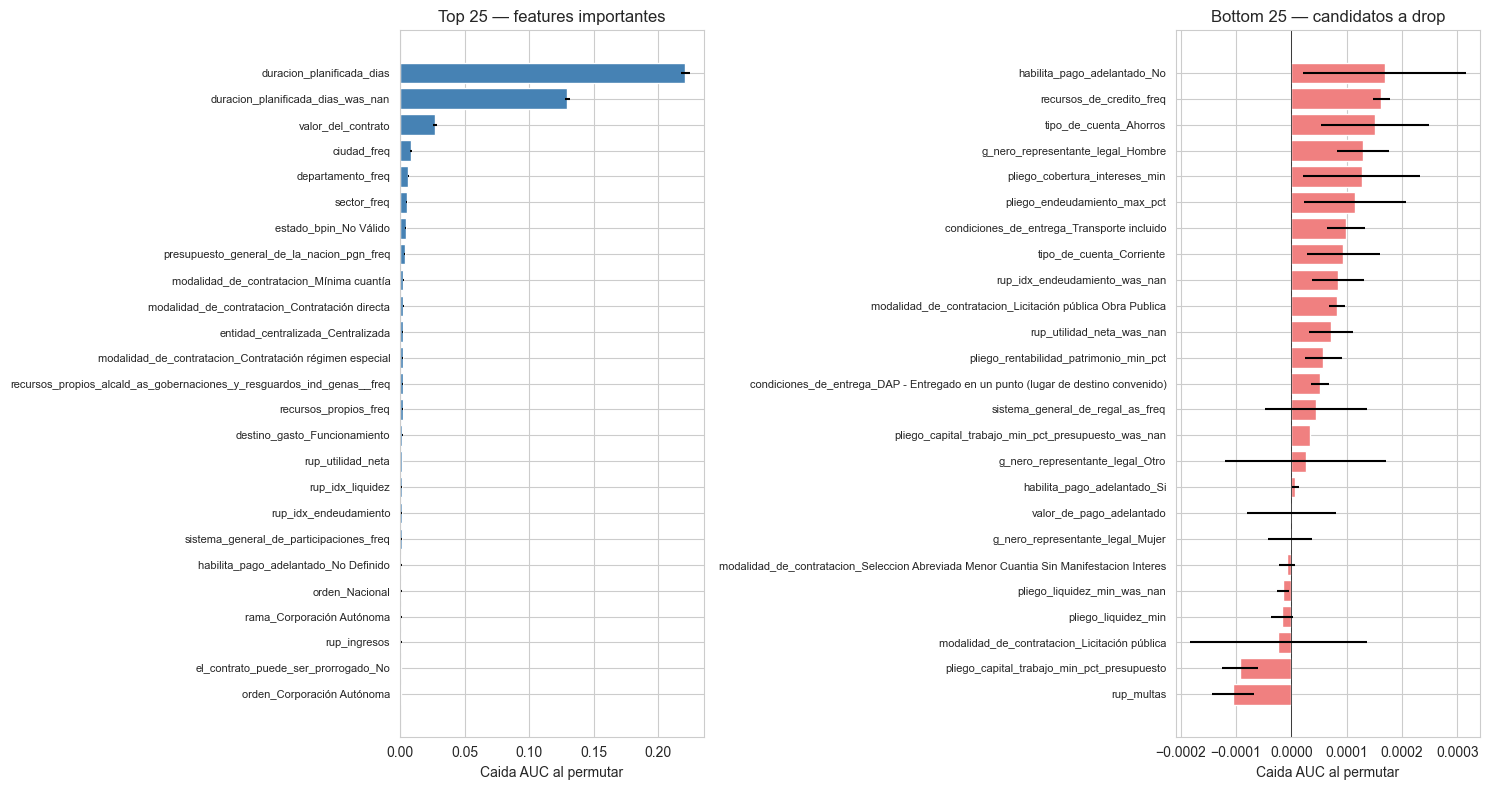

In [7]:
# Plot top 25 + bottom 25
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

top25 = perm_df.head(25).iloc[::-1]
bot25 = perm_df.tail(25).iloc[::-1]

axes[0].barh(top25['feature'], top25['mean_drop_auc'],
              xerr=top25['std_drop_auc'], color='steelblue')
axes[0].set_title('Top 25 — features importantes')
axes[0].set_xlabel('Caida AUC al permutar')
axes[0].tick_params(axis='y', labelsize=8)

axes[1].barh(bot25['feature'], bot25['mean_drop_auc'],
              xerr=bot25['std_drop_auc'], color='lightcoral')
axes[1].set_title('Bottom 25 — candidatos a drop')
axes[1].set_xlabel('Caida AUC al permutar')
axes[1].axvline(0, color='black', lw=0.5)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGS / 'dia_04b_permutation_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# Mantener features con caida AUC > 0 (estricto: contribuyen positivamente)
# Las que tienen mean_drop ≤ 0 probablemente son ruido
UMBRAL_PERM = 0.0

cols_perm_keep = perm_df[perm_df['mean_drop_auc'] > UMBRAL_PERM]['feature'].tolist()
cols_perm_drop = perm_df[perm_df['mean_drop_auc'] <= UMBRAL_PERM]['feature'].tolist()

print(f'Mantener (drop AUC > {UMBRAL_PERM}): {len(cols_perm_keep)}')
print(f'Dropear (no aportan o ruido):       {len(cols_perm_drop)}')

Mantener (drop AUC > 0.0): 59
Dropear (no aportan o ruido):       8


## Paso 4: RFECV (Recursive Feature Elimination con Cross-Validation)

Algoritmo:
1. Entrenar modelo con N features
2. Eliminar la feature con menor importancia
3. Repetir hasta que CV score baje
4. El N óptimo es donde CV score es máximo

**Tarda más** (5-10 min) pero da número óptimo de features con confianza estadística.

In [9]:
# Modelo base mas pequeno para que RFECV no tarde una eternidad
xgb_for_rfe = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    objective='binary:logistic', scale_pos_weight=spw,
    n_jobs=-1, random_state=RANDOM_STATE, tree_method='hist',
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
rfecv = RFECV(
    estimator=xgb_for_rfe,
    step=2,                 # eliminar 2 cols por iteracion
    min_features_to_select=10,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
rfecv.fit(X_train_v2, y_train)
print(f'RFECV terminado en {time.time()-t0:.1f}s')

n_optimo = rfecv.n_features_
cols_rfecv_keep = X_train_v2.columns[rfecv.support_].tolist()
print(f'\nN optimo de features (CV): {n_optimo}')
print(f'Cols seleccionadas: {len(cols_rfecv_keep)}')

RFECV terminado en 14.7s

N optimo de features (CV): 31
Cols seleccionadas: 31


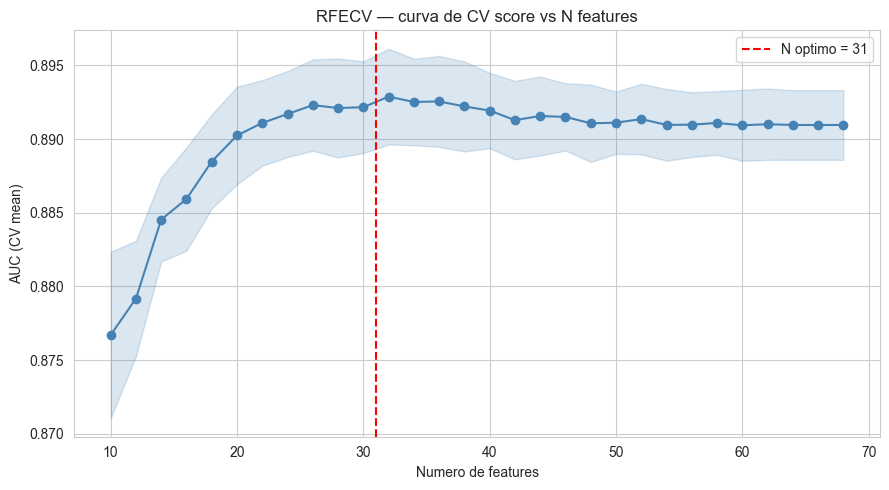

In [10]:
# Curva de CV score vs N features
scores = rfecv.cv_results_['mean_test_score']
stds = rfecv.cv_results_['std_test_score']
n_features_grid = np.arange(rfecv.min_features_to_select,
                              rfecv.min_features_to_select + len(scores) * rfecv.step,
                              rfecv.step)[:len(scores)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_features_grid, scores, 'o-', color='steelblue')
ax.fill_between(n_features_grid, scores - stds, scores + stds, alpha=0.2, color='steelblue')
ax.axvline(n_optimo, color='red', ls='--', label=f'N optimo = {n_optimo}')
ax.set_xlabel('Numero de features')
ax.set_ylabel('AUC (CV mean)')
ax.set_title('RFECV — curva de CV score vs N features')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'dia_04b_rfecv_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Paso 5: Comparativa modelo completo vs reducido

Tomamos la **intersección** entre lo que sobrevive a permutation importance Y RFECV.
Es la selección más conservadora pero confiable.

In [11]:
# Interseccion de los dos métodos
cols_finales = sorted(set(cols_perm_keep) & set(cols_rfecv_keep))
print(f'Permutation keep: {len(cols_perm_keep)}')
print(f'RFECV keep:       {len(cols_rfecv_keep)}')
print(f'Interseccion:     {len(cols_finales)}')
print()
print(f'Reduccion vs original: {X_train.shape[1]} → {len(cols_finales)}  ({(1-len(cols_finales)/X_train.shape[1])*100:.1f}% drop)')

Permutation keep: 59
RFECV keep:       31
Interseccion:     30

Reduccion vs original: 94 → 30  (68.1% drop)


In [12]:
X_train_red = X_train[cols_finales]
X_test_red = X_test[cols_finales]

# Reentrenar XGB sobre dataset reducido
xgbm_red = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=spw, n_jobs=-1, random_state=RANDOM_STATE,
    tree_method='hist',
)
xgbm_red.fit(X_train_red, y_train)

def evaluar(modelo, Xts, yts, label):
    proba = modelo.predict_proba(Xts)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        'version': label, 'n_features': Xts.shape[1],
        'AUC': roc_auc_score(yts, proba),
        'F1': f1_score(yts, pred),
        'Precision': precision_score(yts, pred),
        'Recall': recall_score(yts, pred),
        'Accuracy': accuracy_score(yts, pred),
    }

comp = pd.DataFrame([
    evaluar(xgbm, X_test, y_test, 'Completo (94 cols)'),
    evaluar(xgbm_red, X_test_red, y_test, f'Reducido ({len(cols_finales)} cols)'),
]).round(4)
print(comp.to_string(index=False))

comp.to_csv(DATA / 'comparativa_feature_selection.csv', index=False)

           version  n_features    AUC     F1  Precision  Recall  Accuracy
Completo (94 cols)          94 0.9015 0.8421     0.8801  0.8073    0.8169
Reducido (30 cols)          30 0.9036 0.8441     0.8808  0.8103    0.8190


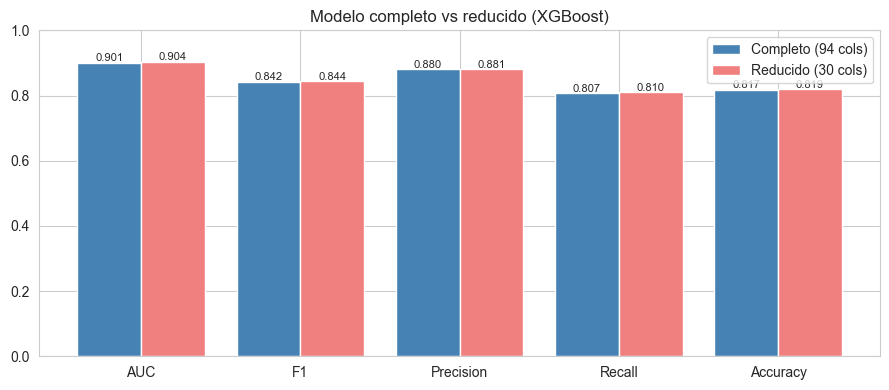

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
metricas = ['AUC', 'F1', 'Precision', 'Recall', 'Accuracy']
x = np.arange(len(metricas))
w = 0.4

vals_full = comp.iloc[0][metricas].values
vals_red = comp.iloc[1][metricas].values

ax.bar(x - w/2, vals_full, w, label=comp.iloc[0]['version'], color='steelblue')
ax.bar(x + w/2, vals_red, w, label=comp.iloc[1]['version'], color='lightcoral')
for i, (vf, vr) in enumerate(zip(vals_full, vals_red)):
    ax.text(i - w/2, vf + 0.005, f'{vf:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, vr + 0.005, f'{vr:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title(f'Modelo completo vs reducido (XGBoost)')
plt.tight_layout()
plt.savefig(FIGS / 'dia_04b_comparativa_reduccion.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Persistir dataset reducido

In [14]:
# Guardar dataset reducido
X_train_red.to_parquet(DATA / 'X_train_reducido.parquet', index=False)
X_test_red.to_parquet(DATA / 'X_test_reducido.parquet', index=False)
joblib.dump(xgbm_red, MODELOS / 'xgb_reducido.pkl')

# Lista de features finales
feats_df = pd.DataFrame({
    'feature': cols_finales,
    'survives_variance': True,
    'survives_correlation': True,
    'survives_permutation': [c in cols_perm_keep for c in cols_finales],
    'survives_rfecv': [c in cols_rfecv_keep for c in cols_finales],
})
feats_df.to_csv(DATA / 'features_seleccionadas.csv', index=False)

print(f'Persistidos:')
print(f'  X_train_reducido.parquet  ({X_train_red.shape})')
print(f'  X_test_reducido.parquet   ({X_test_red.shape})')
print(f'  features_seleccionadas.csv  ({len(cols_finales)} features)')
print(f'  modelos/xgb_reducido.pkl')

Persistidos:
  X_train_reducido.parquet  ((38664, 30))
  X_test_reducido.parquet   ((9667, 30))
  features_seleccionadas.csv  (30 features)
  modelos/xgb_reducido.pkl


## Conclusiones

Pipeline aplicado en orden:
1. Variance threshold → drop cols cuasi-constantes
2. Correlation filter → drop redundantes (|corr| > 0.95)
3. Permutation importance → drop con caída AUC ≤ 0
4. RFECV → confirma N óptimo via CV
5. **Intersección** de (3) y (4) → features finales conservadoras

Si la métrica AUC del reducido es **igual o mejor** que el completo:
✅ La reducción fue exitosa, mejor generalización con menos cols.

Si AUC bajó **< 0.005**: aceptable. Modelo más simple y rápido.

Si AUC bajó **> 0.01**: revisar — quizás dropé features importantes.

## Próximo (Día 5)

Usar `X_train_reducido` y `X_test_reducido` en hyperparameter tuning.
Random Search 80 iters × 2 modelos × CV 5-fold sobre dataset reducido (más rápido).